# Empirical CDF

**Module 3: Probability Distributions** | Lean Six Sigma Data Analytics

---

## Purpose

The **Empirical CDF** is used to calculate probabilities and percentages:

- How many percent of cases meet your **service level agreement (SLA)**?
- How many percent of cases meet your **specifications**?

You will use this tool in the **Analyze phase** of your Lean Six Sigma project.

In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')

Data loaded successfully!


---

## Example: Call Center Total Handling Time

You run a project in a call center to improve **Total Handling Time (THT)**.

**Question:** How often do employees handle a call within **240 seconds** (your target)?

In [3]:
# Load Total Handling Time (THT) data
tht_df = pd.read_excel(xlsx, sheet_name='THT', skiprows=8)
tht_df.columns = ['THT', 'Training', 'Extra']
tht_df = tht_df[['THT']].dropna()
tht_df['THT'] = pd.to_numeric(tht_df['THT'], errors='coerce')
tht_df = tht_df.dropna()

tht_data = tht_df['THT'].values

print('Total Handling Time (THT) Data')
print(f'Sample size: {len(tht_data)}')
print(f'Mean: {tht_data.mean():.1f} seconds')
print(f'Median: {np.median(tht_data):.1f} seconds')

Total Handling Time (THT) Data
Sample size: 56
Mean: 280.3 seconds
Median: 211.5 seconds


---

## The Counting Approach (Limited)

One way to answer: sort the data, count how many are below 240 seconds.

In [4]:
# Simple counting approach
target = 240
count_below = (tht_data <= target).sum()
pct_below = count_below / len(tht_data) * 100

print(f'Counting Approach:')
print(f'  Calls handled within {target} seconds: {count_below} out of {len(tht_data)}')
print(f'  Percentage: {pct_below:.1f}%')
print()
print('LIMITATION:')
print('  This is only precise with large datasets (300+ observations).')
print('  With small samples, we need the Empirical CDF for accurate estimates.')

Counting Approach:
  Calls handled within 240 seconds: 34 out of 56
  Percentage: 60.7%

LIMITATION:
  This is only precise with large datasets (300+ observations).
  With small samples, we need the Empirical CDF for accurate estimates.


---

## The Empirical CDF Approach

From the probability plot (previous video), we know THT is **lognormally distributed**.

The Empirical CDF shows:
- **Blue curve:** The sample data (empirical)
- **Red curve:** The fitted distribution (model for population)

**Minitab:** Graph > Empirical CDF > Single

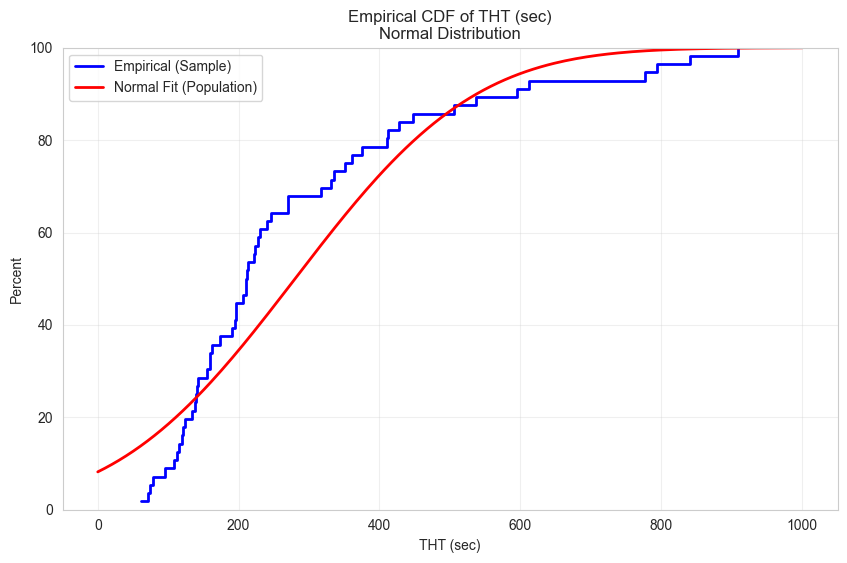

Notice: The blue and red curves do NOT overlap well.
This confirms Normal is NOT a good fit for this data.


In [5]:
# Empirical CDF with Normal Distribution
# Equivalent to Minitab: Graph > Empirical CDF > Single > Normal

fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF (blue step function)
sorted_data = np.sort(tht_data)
ecdf_y = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
ax.step(sorted_data, ecdf_y, where='post', color='blue', lw=2, label='Empirical (Sample)')

# Fitted Normal CDF (red curve)
mu, sigma = tht_data.mean(), tht_data.std()
x_range = np.linspace(0, tht_data.max() * 1.1, 200)
normal_cdf = stats.norm.cdf(x_range, mu, sigma) * 100
ax.plot(x_range, normal_cdf, 'r-', lw=2, label='Normal Fit (Population)')

ax.set_xlabel('THT (sec)')
ax.set_ylabel('Percent')
ax.set_title('Empirical CDF of THT (sec)\nNormal Distribution')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.show()

print('Notice: The blue and red curves do NOT overlap well.')
print('This confirms Normal is NOT a good fit for this data.')

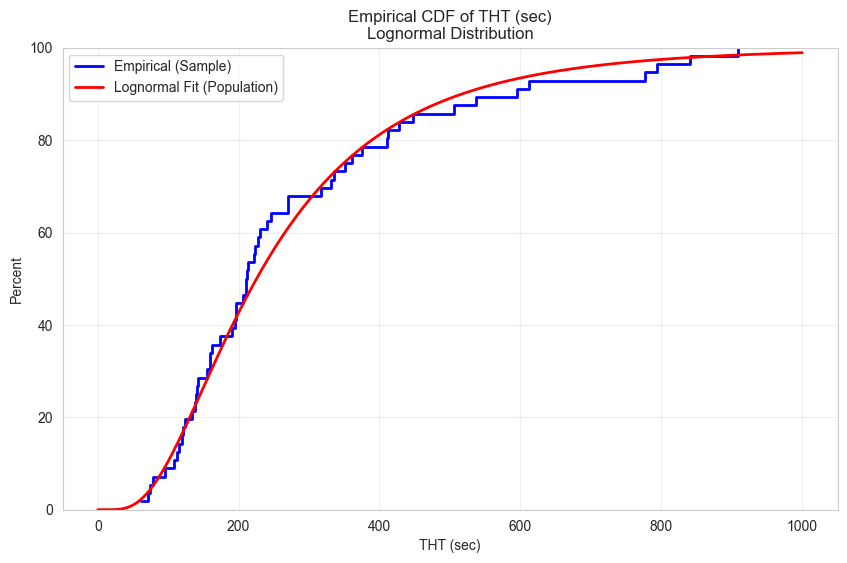

Notice: The blue and red curves overlap almost perfectly!
This confirms Lognormal IS a good fit for this data.


In [6]:
# Empirical CDF with Lognormal Distribution
# Equivalent to Minitab: Graph > Empirical CDF > Single > Lognormal

fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF (blue step function)
ax.step(sorted_data, ecdf_y, where='post', color='blue', lw=2, label='Empirical (Sample)')

# Fitted Lognormal CDF (red curve)
log_data = np.log(tht_data)
mu_log, sigma_log = log_data.mean(), log_data.std()
lognorm_cdf = stats.lognorm.cdf(x_range, s=sigma_log, scale=np.exp(mu_log)) * 100
ax.plot(x_range, lognorm_cdf, 'r-', lw=2, label='Lognormal Fit (Population)')

ax.set_xlabel('THT (sec)')
ax.set_ylabel('Percent')
ax.set_title('Empirical CDF of THT (sec)\nLognormal Distribution')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.show()

print('Notice: The blue and red curves overlap almost perfectly!')
print('This confirms Lognormal IS a good fit for this data.')

---

## Using the Empirical CDF to Calculate Probabilities

Now we can use the fitted lognormal distribution to answer questions:

1. **What % of calls are handled within X seconds?** (X → Percent)
2. **At what time are Y% of calls handled?** (Percent → X)

In [7]:
# Question 1: What % of calls are handled within 240 seconds?
target_240 = 240
pct_240 = stats.lognorm.cdf(target_240, s=sigma_log, scale=np.exp(mu_log)) * 100

print('QUESTION 1: What % of calls are handled within 240 seconds?')
print(f'  Answer: {pct_240:.1f}% of calls are handled within {target_240} seconds')
print()

QUESTION 1: What % of calls are handled within 240 seconds?
  Answer: 53.8% of calls are handled within 240 seconds



In [8]:
# Question 2: What % of calls are handled within 600 seconds?
target_600 = 600
pct_600 = stats.lognorm.cdf(target_600, s=sigma_log, scale=np.exp(mu_log)) * 100

print('QUESTION 2: What % of calls are handled within 600 seconds?')
print(f'  Answer: {pct_600:.1f}% of calls are handled within {target_600} seconds')
print()

QUESTION 2: What % of calls are handled within 600 seconds?
  Answer: 93.4% of calls are handled within 600 seconds



In [9]:
# Question 3: What service level can I promise for 95% of calls?
target_pct = 95
time_95 = stats.lognorm.ppf(target_pct / 100, s=sigma_log, scale=np.exp(mu_log))

print('QUESTION 3: What service level can I promise for 95% of calls?')
print(f'  Answer: In {target_pct}% of calls, we will be done within {time_95:.0f} seconds')
print()

QUESTION 3: What service level can I promise for 95% of calls?
  Answer: In 95% of calls, we will be done within 655 seconds



---

## Visualizing the Answers

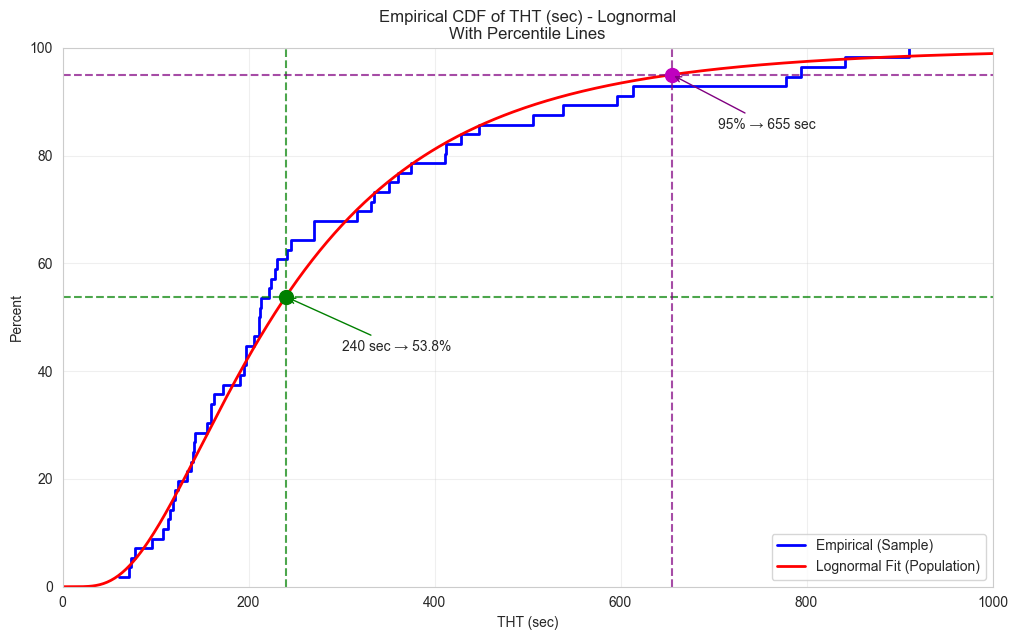

In [10]:
# Empirical CDF with percentile lines
# Equivalent to Minitab crosshairs and percentile lines

fig, ax = plt.subplots(figsize=(12, 7))

# Empirical CDF
ax.step(sorted_data, ecdf_y, where='post', color='blue', lw=2, label='Empirical (Sample)')

# Fitted Lognormal CDF
x_range = np.linspace(0, 1000, 500)
lognorm_cdf = stats.lognorm.cdf(x_range, s=sigma_log, scale=np.exp(mu_log)) * 100
ax.plot(x_range, lognorm_cdf, 'r-', lw=2, label='Lognormal Fit (Population)')

# Percentile lines for 240 seconds
ax.axvline(x=240, color='green', linestyle='--', alpha=0.7)
ax.axhline(y=pct_240, color='green', linestyle='--', alpha=0.7)
ax.plot(240, pct_240, 'go', markersize=10)
ax.annotate(f'240 sec → {pct_240:.1f}%', xy=(240, pct_240), xytext=(300, pct_240-10),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='green'))

# Percentile lines for 95%
ax.axvline(x=time_95, color='purple', linestyle='--', alpha=0.7)
ax.axhline(y=95, color='purple', linestyle='--', alpha=0.7)
ax.plot(time_95, 95, 'mo', markersize=10)
ax.annotate(f'95% → {time_95:.0f} sec', xy=(time_95, 95), xytext=(time_95+50, 85),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='purple'))

ax.set_xlabel('THT (sec)')
ax.set_ylabel('Percent')
ax.set_title('Empirical CDF of THT (sec) - Lognormal\nWith Percentile Lines')
ax.legend(loc='lower right')
ax.set_xlim(0, 1000)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.show()

---

## Summary of Calculations

In [11]:
# Summary table
print('EMPIRICAL CDF RESULTS')
print('=' * 60)
print(f'Distribution: Lognormal (Loc={mu_log:.3f}, Scale={sigma_log:.3f})')
print()
print('Time → Percent:')
print(f'  Within 240 sec: {pct_240:.1f}% of calls')
print(f'  Within 600 sec: {pct_600:.1f}% of calls')
print()
print('Percent → Time (Service Level Promise):')
for pct in [50, 75, 90, 95, 99]:
    time_val = stats.lognorm.ppf(pct / 100, s=sigma_log, scale=np.exp(mu_log))
    print(f'  {pct}% of calls: within {time_val:.0f} seconds')

EMPIRICAL CDF RESULTS
Distribution: Lognormal (Loc=5.419, Scale=0.648)

Time → Percent:
  Within 240 sec: 53.8% of calls
  Within 600 sec: 93.4% of calls

Percent → Time (Service Level Promise):
  50% of calls: within 226 seconds
  75% of calls: within 349 seconds
  90% of calls: within 518 seconds
  95% of calls: within 655 seconds
  99% of calls: within 1019 seconds


---

## Key Takeaways

- **First:** Use probability plot to find the distribution (Normal, Weibull, Lognormal)
- **Then:** Use Empirical CDF to calculate percentages
- **Blue curve:** Empirical data (sample)
- **Red curve:** Fitted distribution (population model)
- **Good fit:** Curves overlap almost perfectly
- **Two types of questions:**
  - Time → Percent: "What % within X seconds?"
  - Percent → Time: "At what time are Y% complete?"
- **Use in Analyze phase** of Lean Six Sigma projects